# ICS1502 – Introduction to Machine Learning
## CAT Assignment 2 – Bank Note Authentication (Binary Classification)
*NAME: LEKHA SHREE*
*REGISTER NUMBER: 3122247001031*
**Programme:** M.Tech (Integrated) CSE, Semester V  |  **Batch:** 2024–2029  

**Goal.** Fit a linear classifier (Logistic Regression) and neural networks (single- and multi-layer perceptrons) on the *Bank Note Authentication* dataset, and critically compare them on **accuracy, generalisation, robustness to outliers and interpretability**. The notebook then studies regularisation, 3-D decision boundaries, PCA, and finally tests whether the performance differences are statistically significant (Friedman test + one-way ANOVA).

| Task | Section |
|---|---|
| 1. Linear baseline, with and without L2 | §2 |
| 2. Effect of regularisation strength λ | §3 |
| 3. 3-D decision boundary | §4 |
| 4. Neural-network comparison (+ outliers, interpretability) | §5 |
| 5. PCA | §6 |
| 6. Friedman test and one-way ANOVA | §7 |
| Final verdict – linear vs neural network | §8 |

## 0. Setup

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3-D projection)
from scipy import stats

from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_val_score, cross_validate, learning_curve)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay, silhouette_score)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

def savefig(name):
    plt.savefig(f"figures/{name}.png", dpi=160, bbox_inches="tight")

## 1. Data loading and exploratory analysis
The UCI *Banknote Authentication* data has 1,372 images of genuine / forged banknotes. Each image is summarised by four wavelet-transform features: **variance, skewness, curtosis, entropy**; the target is a binary class (0 / 1).

In [2]:
FEATURES = ["variance", "skewness", "curtosis", "entropy"]
COLS = FEATURES + ["class"]
LOCAL = "data_banknote_authentication.csv"
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"

df = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL, header=None, names=COLS)
print("Raw shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# Exact duplicate rows would let the same note appear in both train and test, inflating accuracy -> drop them.
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
df.describe().T.round(3)

Raw shape: (1372, 5)
Missing values: 0
Duplicate rows: 24
Shape after removing duplicates: (1348, 5)


,count,mean,std,min,25%,50%,75%,max
variance,1348.0,0.446,2.863,-7.042,-1.787,0.519,2.853,6.825
skewness,1348.0,1.909,5.869,-13.773,-1.627,2.334,6.796,12.952
curtosis,1348.0,1.414,4.328,-5.286,-1.546,0.605,3.200,17.927
entropy,1348.0,-1.169,2.086,-8.548,-2.393,-0.579,0.404,2.450
class,1348.0,0.453,0.498,0.000,0.000,0.000,1.000,1.000


Class balance (after de-duplication):
       count  share
class              
0        738  0.547
1        610  0.453

IQR-rule outliers per feature:
 variance     0
skewness     0
curtosis    59
entropy     32


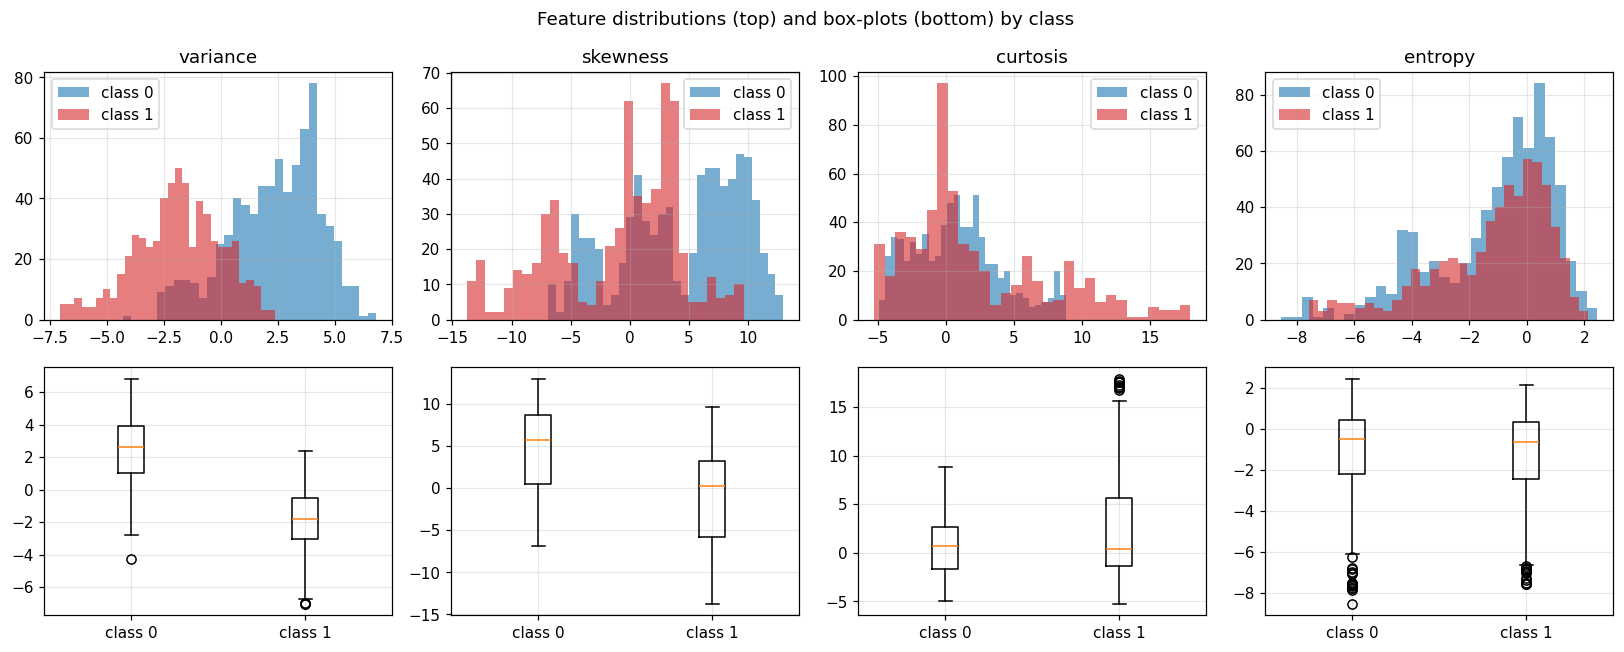

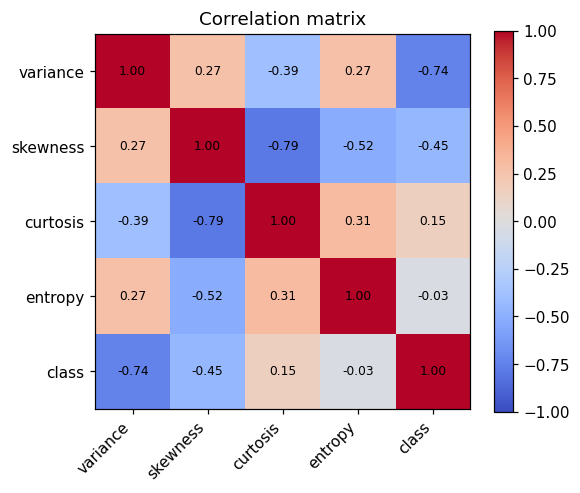

In [3]:
print("Class balance (after de-duplication):")
print(df["class"].value_counts().rename("count").to_frame().assign(share=lambda d: (d["count"] / len(df)).round(3)))

# IQR-rule outlier count per feature
q1, q3 = df[FEATURES].quantile(0.25), df[FEATURES].quantile(0.75)
iqr = q3 - q1
out_counts = ((df[FEATURES] < q1 - 1.5 * iqr) | (df[FEATURES] > q3 + 1.5 * iqr)).sum()
print("\nIQR-rule outliers per feature:\n", out_counts.to_string())

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i, f in enumerate(FEATURES):
    for c, col in zip([0, 1], ["tab:blue", "tab:red"]):
        axes[0, i].hist(df.loc[df["class"] == c, f], bins=30, alpha=0.6, label=f"class {c}", color=col)
    axes[0, i].set_title(f); axes[0, i].legend()
    axes[1, i].boxplot([df.loc[df["class"] == c, f] for c in [0, 1]], labels=["class 0", "class 1"])
plt.suptitle("Feature distributions (top) and box-plots (bottom) by class")
plt.tight_layout(); savefig("01_eda_distributions"); plt.show()

corr = df[FEATURES + ["class"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(corr.columns); ax.grid(False)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.title("Correlation matrix"); savefig("02_correlation"); plt.show()

### Train / test split and scaling
A stratified 80 / 20 split is used. The scaler is **fitted on the training data only** (no leakage). `X_train_raw` is kept for pipelines that must re-fit the scaler inside cross-validation.

In [4]:
X = df[FEATURES].values
y = df["class"].values
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
scaler = StandardScaler().fit(X_train_raw)
X_train, X_test = scaler.transform(X_train_raw), scaler.transform(X_test_raw)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, positives in train/test: {y_train.mean():.3f}/{y_test.mean():.3f}")

def metrics_row(name, model, Xtr=None, ytr=None, Xte=None, yte=None):
    Xtr = X_train if Xtr is None else Xtr; ytr = y_train if ytr is None else ytr
    Xte = X_test if Xte is None else Xte;  yte = y_test if yte is None else yte
    ptr, pte = model.predict(Xtr), model.predict(Xte)
    return {"Model": name,
            "Train acc": accuracy_score(ytr, ptr), "Test acc": accuracy_score(yte, pte),
            "Gap (train-test)": accuracy_score(ytr, ptr) - accuracy_score(yte, pte),
            "Precision": precision_score(yte, pte), "Recall": recall_score(yte, pte),
            "F1": f1_score(yte, pte), "ROC-AUC": roc_auc_score(yte, model.predict_proba(Xte)[:, 1])}

Train: (1078, 4), Test: (270, 4), positives in train/test: 0.453/0.452


## 2. Linear model baseline – Logistic Regression with and without L2 regularisation
Logistic regression models $P(y=1\mid x)=\sigma(w^\top x+b)$. With L2 regularisation the loss is
$\;\mathcal{L}(w)=\sum_i \log\!\big(1+e^{-\tilde y_i (w^\top x_i+b)}\big)+\tfrac{\lambda}{2}\lVert w\rVert_2^2\;$, where scikit-learn's `C = 1/λ`.

In [5]:
lr_none = LogisticRegression(penalty=None, max_iter=10000).fit(X_train, y_train)
lr_l2 = LogisticRegression(penalty="l2", C=1.0, max_iter=10000).fit(X_train, y_train)   # λ = 1

cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
rows = []
for name, m, mk in [("LR – no regularisation", lr_none, lambda: LogisticRegression(penalty=None, max_iter=10000)),
                    ("LR – L2 (λ = 1)", lr_l2, lambda: LogisticRegression(C=1.0, max_iter=10000))]:
    r = metrics_row(name, m)
    r["5-fold CV acc"] = cross_val_score(make_pipeline(StandardScaler(), mk()), X_train_raw, y_train, cv=cv5).mean()
    r["‖w‖₂"] = np.linalg.norm(m.coef_)
    rows.append(r)
baseline = pd.DataFrame(rows).set_index("Model")
baseline.round(4)

,Train acc,Test acc,Gap (train-test),Precision,Recall,F1,ROC-AUC,5-fold CV acc,‖w‖₂
Model,,,,,,,,,
LR – no regularisation,0.9972,0.9926,0.0046,0.9839,1.0,0.9919,1.0,0.9963,33.8369
LR – L2 (λ = 1),0.9944,0.9852,0.0092,0.9683,1.0,0.9839,1.0,0.9944,7.9577


### Interpretation – Task 1
*(Numbers in the commentary are from the run saved in this notebook, `random_state = 42`; other library versions may shift the last digit.)*

| | Train acc | Test acc | 5-fold CV | ‖w‖₂ |
|---|---|---|---|---|
| No regularisation | 99.72 % | 99.26 % | 99.63 % | 33.8 |
| L2, λ = 1 | 99.44 % | 98.52 % | 99.44 % | 8.0 |

* Both models are excellent and the train–test gap is below 1 pp, so **there is no real over-fitting** to cure: the data are low-dimensional (4 features, 1,078 training rows) and almost linearly separable.
* L2 shrinks the weight vector four-fold (33.8 → 8.0) but λ = 1 slightly *lowers* accuracy. On a 270-row test set the 0.74 pp difference is **two notes**, i.e. within noise, but it clearly gives no benefit.
* The very large unregularised weights are a symptom of near-separability: without a penalty the optimiser keeps inflating ‖w‖ to push the logistic probabilities to 0/1. The penalty mainly buys *numerical stability and calibrated probabilities*, not accuracy.
* Recall is 100 % for both models, so every error is a false positive (a class-0 note labelled class 1); precision is 98.4 % vs 96.8 %.

## 3. Effect of the regularisation strength λ
λ is swept over seven decades. Besides the train/test curves, λ is chosen on **cross-validation within the training set** (never on the test set). Because this dataset is almost linearly separable and large, the effect of λ is small on the full training set, so a second experiment uses very small training subsets, where over-fitting is much easier to provoke.

Best λ from 5-fold CV = 0.00161 (C = 621),  CV acc = 0.9972


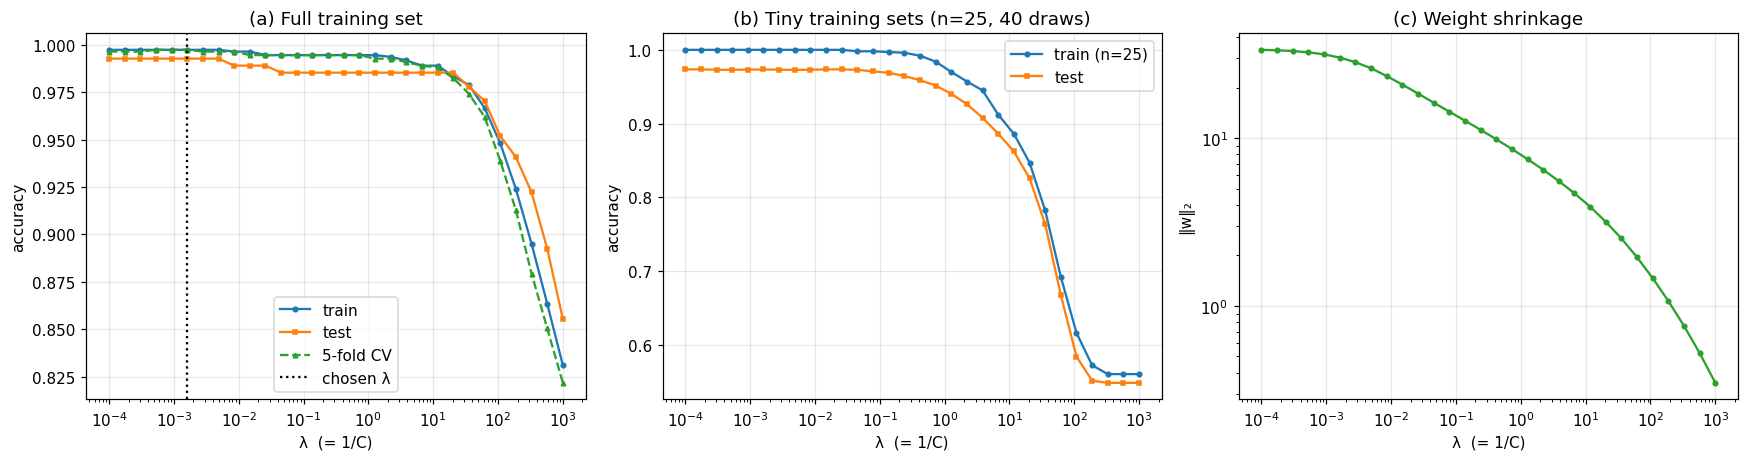

,λ,train acc,test acc,CV acc,‖w‖₂,train acc (n=25),test acc (n=25)
0,0.0001,0.9972,0.9926,0.9963,33.5507,1.000,0.9734
1,0.0005,0.9972,0.9926,0.9972,32.4252,1.000,0.9729
2,0.0028,0.9972,0.9926,0.9963,28.3144,1.000,0.9731
3,0.0149,0.9963,0.9889,0.9944,20.8416,1.000,0.9734
4,0.0788,0.9944,0.9852,0.9944,14.3704,0.998,0.9708
5,0.4175,0.9944,0.9852,0.9944,9.8397,0.992,0.9587
6,2.2122,0.9935,0.9852,0.9926,6.4732,0.957,0.9263
7,11.7210,0.9889,0.9852,0.9879,3.8997,0.886,0.8621
8,62.1017,0.9666,0.9704,0.9620,1.9484,0.692,0.6672
9,329.0345,0.8952,0.9222,0.8794,0.7604,0.560,0.5481


In [6]:
lambdas = np.logspace(-4, 3, 30)
tr_acc, te_acc, cv_acc, w_norm = [], [], [], []
for lam in lambdas:
    m = LogisticRegression(C=1 / lam, max_iter=10000).fit(X_train, y_train)
    tr_acc.append(m.score(X_train, y_train)); te_acc.append(m.score(X_test, y_test)); w_norm.append(np.linalg.norm(m.coef_))
    cv_acc.append(cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(C=1 / lam, max_iter=10000)),
                                  X_train_raw, y_train, cv=cv5).mean())
tr_acc, te_acc, cv_acc, w_norm = map(np.array, (tr_acc, te_acc, cv_acc, w_norm))

# Best λ = strongest regularisation that is still within 1e-12 of the best CV accuracy (prefers the simpler model)
best_idx = np.where(cv_acc >= cv_acc.max() - 1e-12)[0].max()
BEST_LAMBDA, BEST_C = lambdas[best_idx], 1 / lambdas[best_idx]
print(f"Best λ from 5-fold CV = {BEST_LAMBDA:.4g} (C = {BEST_C:.4g}),  CV acc = {cv_acc[best_idx]:.4f}")

# --- Experiment B: small training subsets (n = 25), averaged over 40 random draws
rng = np.random.default_rng(SEED)
N_SMALL, REPS = 25, 40
tr_small, te_small = np.zeros(len(lambdas)), np.zeros(len(lambdas))
for _ in range(REPS):
    sub, _ = train_test_split(np.arange(len(y_train)), train_size=N_SMALL, stratify=y_train, random_state=int(rng.integers(1e9)))
    for k, lam in enumerate(lambdas):
        m = LogisticRegression(C=1 / lam, max_iter=10000).fit(X_train[sub], y_train[sub])
        tr_small[k] += m.score(X_train[sub], y_train[sub]) / REPS; te_small[k] += m.score(X_test, y_test) / REPS

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].semilogx(lambdas, tr_acc, "o-", ms=3, label="train"); ax[0].semilogx(lambdas, te_acc, "s-", ms=3, label="test")
ax[0].semilogx(lambdas, cv_acc, "^--", ms=3, label="5-fold CV"); ax[0].axvline(BEST_LAMBDA, color="k", ls=":", label="chosen λ")
ax[0].set(xlabel="λ  (= 1/C)", ylabel="accuracy", title="(a) Full training set"); ax[0].legend()
ax[1].semilogx(lambdas, tr_small, "o-", ms=3, label="train (n=25)"); ax[1].semilogx(lambdas, te_small, "s-", ms=3, label="test")
ax[1].set(xlabel="λ  (= 1/C)", ylabel="accuracy", title="(b) Tiny training sets (n=25, 40 draws)"); ax[1].legend()
ax[2].loglog(lambdas, w_norm, "o-", ms=3, color="tab:green")
ax[2].set(xlabel="λ  (= 1/C)", ylabel="‖w‖₂", title="(c) Weight shrinkage")
plt.tight_layout(); savefig("03_regularisation_effect"); plt.show()

reg_table = pd.DataFrame({"λ": lambdas, "train acc": tr_acc, "test acc": te_acc, "CV acc": cv_acc, "‖w‖₂": w_norm,
                          "train acc (n=25)": tr_small, "test acc (n=25)": te_small})
reg_table.iloc[::3].round(4).reset_index(drop=True)

### Interpretation – Task 2
* **Full training set (panel a).** Accuracy is flat (≈ 99.3 % test, 99.6–99.7 % CV) for λ from 10⁻⁴ up to about 10⁻²; it decays slowly up to λ ≈ 10 and collapses beyond λ ≈ 60 (CV 96.2 % at λ = 62, 87.9 % at λ = 329) because the weights are shrunk so far that the model **under-fits** (panel c). The CV-optimal λ is tiny (≈ 0.0016, C ≈ 620), i.e. the data want almost no regularisation.
* **Tiny training sets (panel b, n = 25).** Here over-fitting is possible – training accuracy is 100 % at small λ while test accuracy is ≈ 97.3 % – but increasing λ lowers *both* curves (test 92.6 % at λ ≈ 2, 66.7 % at λ ≈ 60). Even with 25 samples the extra variance of a 5-parameter linear model is smaller than the bias introduced by shrinkage.
* **Conclusion.** Regularisation strength is a bias–variance dial and for this problem the sweet spot is "weak". Over-fitting is not the issue for a linear model on 4 informative features; large λ only causes under-fitting. Regularisation would matter more with many correlated or noisy features, or much less data per feature.

## 4. Decision-boundary visualisation in a 3-D feature space
Three features are selected using the training data only (ANOVA F-score, cross-checked with mutual information). A logistic regression is fitted in that 3-D space; its decision boundary $w^\top x + b = 0$ is a **plane**, which is drawn over the (standardised) data.

           ANOVA F  Mutual info
variance  1266.805        0.368
skewness   279.009        0.229
curtosis    27.782        0.114
entropy      1.327        0.000

Selected features: ['variance', 'skewness', 'curtosis']
3-feature LR: train acc = 0.9963, test acc = 0.9852
4-feature LR: train acc = 0.9944, test acc = 0.9852


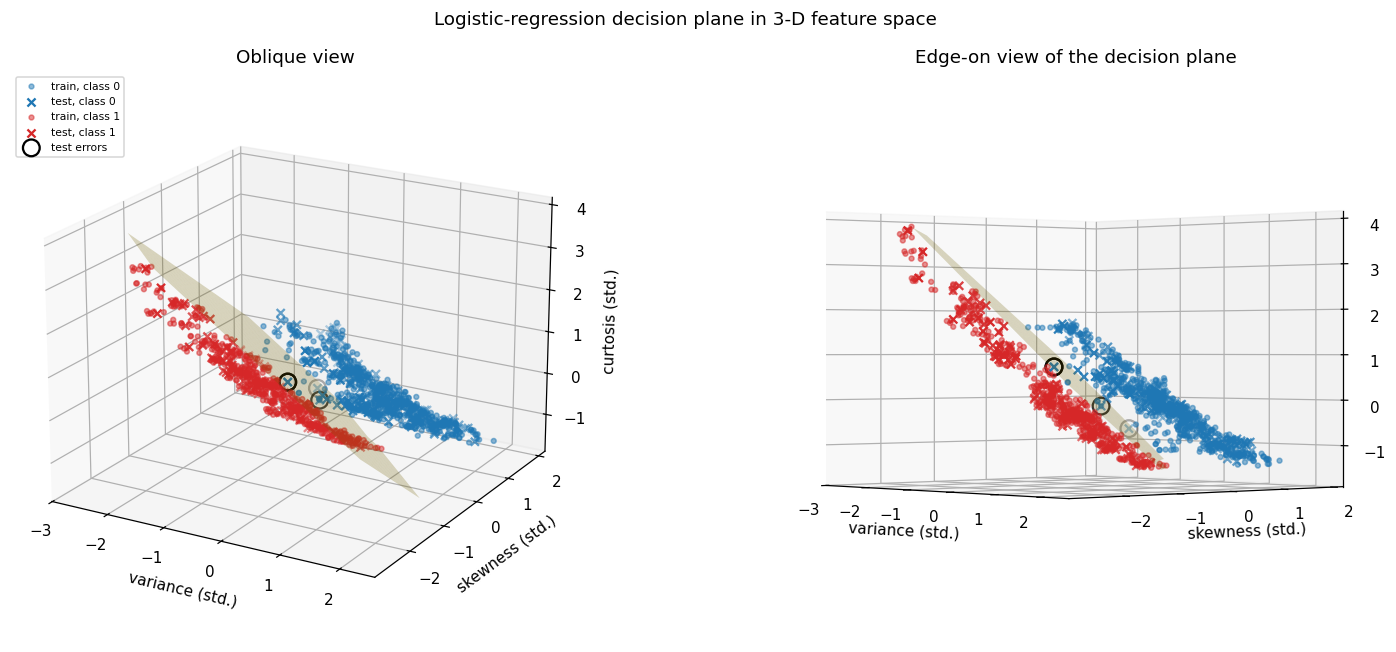

Silhouette score (3-D, true labels): 0.263
class 0: mean distance to plane = 0.75 σ,  points within 0.25σ of the plane = 21 / 590
class 1: mean distance to plane = 0.44 σ,  points within 0.25σ of the plane = 74 / 488
Test errors: 4 of 270


In [7]:
f_scores, _ = f_classif(X_train, y_train)
mi = mutual_info_classif(X_train, y_train, random_state=SEED)
rank_df = pd.DataFrame({"ANOVA F": f_scores, "Mutual info": mi}, index=FEATURES).sort_values("ANOVA F", ascending=False)
print(rank_df.round(3))
top3 = list(rank_df.index[:3]); idx3 = [FEATURES.index(f) for f in top3]
print("\nSelected features:", top3)

Xtr3, Xte3 = X_train[:, idx3], X_test[:, idx3]
lr3 = LogisticRegression(C=BEST_C, max_iter=10000).fit(Xtr3, y_train)
w, b = lr3.coef_[0], lr3.intercept_[0]
print(f"3-feature LR: train acc = {lr3.score(Xtr3, y_train):.4f}, test acc = {lr3.score(Xte3, y_test):.4f}")
print(f"4-feature LR: train acc = {lr_l2.score(X_train, y_train):.4f}, test acc = {lr_l2.score(X_test, y_test):.4f}")

def plot_3d(ax, elev, azim):
    xx, yy = np.meshgrid(np.linspace(Xtr3[:, 0].min(), Xtr3[:, 0].max(), 30), np.linspace(Xtr3[:, 1].min(), Xtr3[:, 1].max(), 30))
    zz = -(b + w[0] * xx + w[1] * yy) / w[2]
    zz = np.where((zz >= Xtr3[:, 2].min()) & (zz <= Xtr3[:, 2].max()), zz, np.nan)
    ax.plot_surface(xx, yy, zz, alpha=0.25, color="gold", linewidth=0)
    for c, col in zip([0, 1], ["tab:blue", "tab:red"]):
        ax.scatter(*Xtr3[y_train == c].T, c=col, s=10, alpha=0.5, label=f"train, class {c}")
        ax.scatter(*Xte3[y_test == c].T, c=col, s=28, marker="x", label=f"test, class {c}")
    wrong = lr3.predict(Xte3) != y_test
    if wrong.any():
        ax.scatter(*Xte3[wrong].T, facecolors="none", edgecolors="k", s=120, linewidths=1.5, label="test errors")
    ax.set_xlabel(f"{top3[0]} (std.)"); ax.set_ylabel(f"{top3[1]} (std.)"); ax.set_zlabel(f"{top3[2]} (std.)")
    ax.view_init(elev, azim)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121, projection="3d"); plot_3d(ax1, 20, -60); ax1.legend(fontsize=7, loc="upper left")
edge_azim = np.degrees(np.arctan2(w[1], w[0])) + 90     # camera direction lies inside the plane -> plane seen edge-on
ax2 = fig.add_subplot(122, projection="3d"); plot_3d(ax2, 0, edge_azim); ax1.set_title("Oblique view"); ax2.set_title("Edge-on view of the decision plane")
plt.suptitle("Logistic-regression decision plane in 3-D feature space")
plt.tight_layout(); savefig("04_decision_boundary_3d"); plt.show()

# Quantitative separability
signed_d = (Xtr3 @ w + b) / np.linalg.norm(w)
print(f"Silhouette score (3-D, true labels): {silhouette_score(Xtr3, y_train):.3f}")
for c in [0, 1]:
    d = np.abs(signed_d[y_train == c])
    print(f"class {c}: mean distance to plane = {d.mean():.2f} σ,  points within 0.25σ of the plane = {(d < 0.25).sum()} / {len(d)}")
print("Test errors:", int((lr3.predict(Xte3) != y_test).sum()), "of", len(y_test))

### Interpretation – Task 3
* **Feature choice.** ANOVA-F ranks *variance* (F ≈ 1267) ≫ *skewness* (279) ≫ *curtosis* (28) ≫ *entropy* (1.3); mutual information agrees (entropy ≈ 0). Entropy is essentially uninformative, so the 3-D space {variance, skewness, curtosis} loses nothing: the 3-feature model has the **same 98.52 % test accuracy** as the 4-feature model (4 errors in 270).
* **Visual separability.** The two classes form two long, roughly parallel, elongated clouds, and a single plane splits them cleanly over most of their length (edge-on view). Mistakes are concentrated where the clouds approach each other (low variance, near-zero skewness) – the four test errors circled in black lie right next to the plane.
* **Quantitatively.** The mean distance to the plane is 0.75σ for class 0 and 0.44σ for class 1; 21/590 and 74/488 training points lie within 0.25σ of the plane. Class 1 is the tighter, less-margin class. The 3-D silhouette score is only 0.26 – low because the clouds are elongated and adjacent, not because the plane fails; the classifier's accuracy (> 98.5 %) is the better measure.
* **Reading.** The classes are **almost, but not perfectly, linearly separable**. The thin overlap region, and the slight curvature of the two clouds, is exactly where a non-linear model can gain a little – which is what §5 tests.

## 5. Neural-network comparison
Two networks are compared with the tuned linear model: a **single-hidden-layer MLP (8 ReLU units)** and a **two-hidden-layer MLP (16 → 8 ReLU units)**, all trained with Adam, L2 penalty α = 10⁻³, on the same standardised data.

In [8]:
def make_nn1(): return MLPClassifier(hidden_layer_sizes=(8,), alpha=1e-3, max_iter=3000, random_state=SEED)
def make_nn2(): return MLPClassifier(hidden_layer_sizes=(16, 8), alpha=1e-3, max_iter=3000, random_state=SEED)
def make_lr():  return LogisticRegression(C=BEST_C, max_iter=10000)

models = {"Logistic Regression (L2, tuned λ)": make_lr(), "NN – 1 hidden layer (8)": make_nn1(), "NN – 2 hidden layers (16, 8)": make_nn2()}
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    r = metrics_row(name, m)
    cvs = cross_val_score(make_pipeline(StandardScaler(), type(m)(**m.get_params())), X_train_raw, y_train, cv=rkf)
    r["CV acc (mean)"], r["CV acc (std)"] = cvs.mean(), cvs.std()
    rows.append(r)
nn_table = pd.DataFrame(rows).set_index("Model")
nn_table.round(4)

,Train acc,Test acc,Gap (train-test),Precision,Recall,F1,ROC-AUC,CV acc (mean),CV acc (std)
Model,,,,,,,,,
"Logistic Regression (L2, tuned λ)",0.9972,0.9926,0.0046,0.9839,1.0,0.9919,1.0,0.9963,0.0025
NN – 1 hidden layer (8),0.9954,0.9852,0.0102,0.9683,1.0,0.9839,1.0,0.9954,0.0045
"NN – 2 hidden layers (16, 8)",0.9991,0.9926,0.0065,0.9839,1.0,0.9919,1.0,0.9972,0.0033


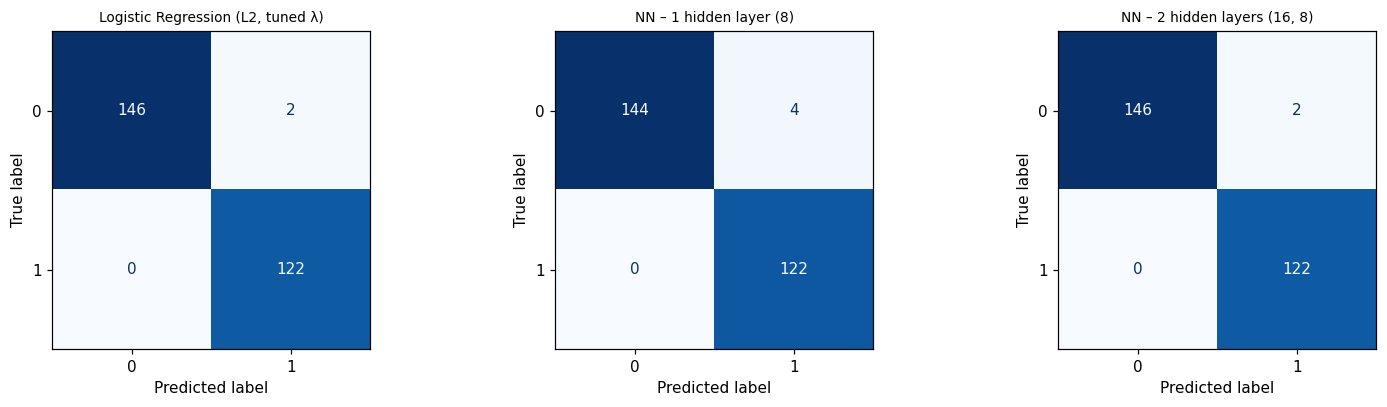

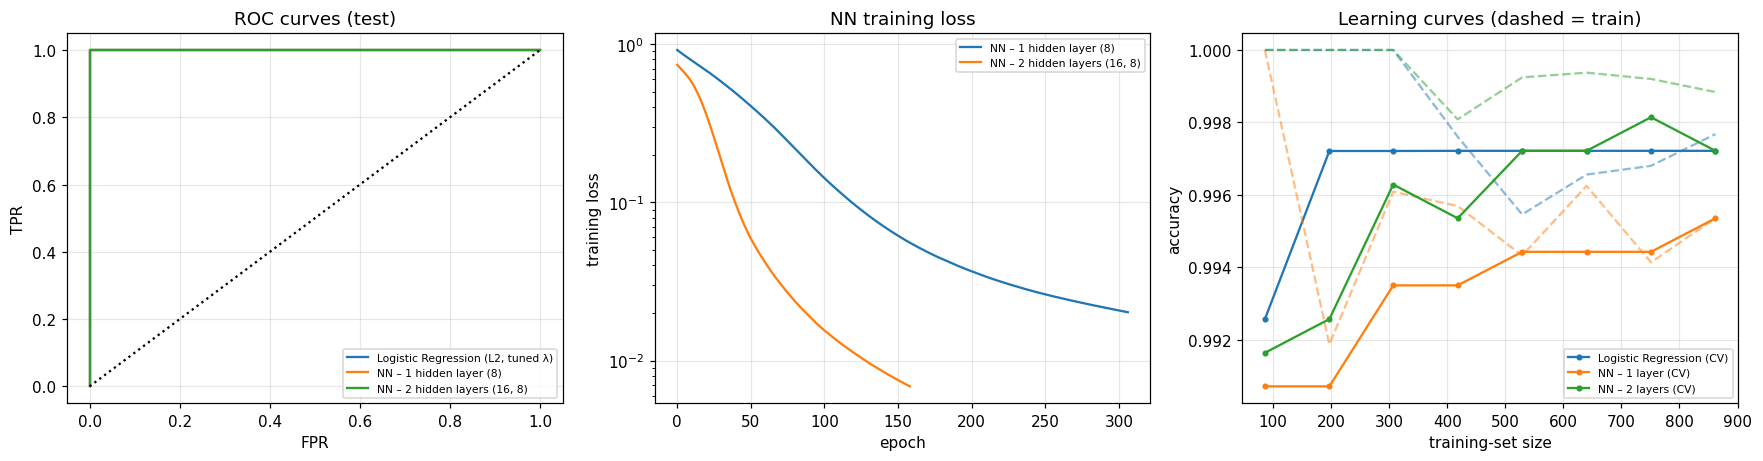

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for a, (name, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, m.predict(X_test))).plot(ax=a, colorbar=False, cmap="Blues")
    a.set_title(name, fontsize=9); a.grid(False)
plt.tight_layout(); savefig("05_confusion_matrices"); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for name, m in models.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1]); ax[0].plot(fpr, tpr, label=name)
ax[0].plot([0, 1], [0, 1], "k:"); ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC curves (test)"); ax[0].legend(fontsize=7)
for name, m in list(models.items())[1:]:
    ax[1].plot(m.loss_curve_, label=name)
ax[1].set(xlabel="epoch", ylabel="training loss", title="NN training loss", yscale="log"); ax[1].legend(fontsize=7)
sizes = np.linspace(0.1, 1.0, 8)
for name, mk in [("Logistic Regression", make_lr), ("NN – 1 layer", make_nn1), ("NN – 2 layers", make_nn2)]:
    ts, trs, vs = learning_curve(make_pipeline(StandardScaler(), mk()), X_train_raw, y_train, train_sizes=sizes, cv=cv5, scoring="accuracy")
    l, = ax[2].plot(ts, vs.mean(1), "o-", ms=3, label=f"{name} (CV)")
    ax[2].plot(ts, trs.mean(1), "--", color=l.get_color(), alpha=0.5)
ax[2].set(xlabel="training-set size", ylabel="accuracy", title="Learning curves (dashed = train)"); ax[2].legend(fontsize=7)
plt.tight_layout(); savefig("06_roc_loss_learning"); plt.show()

### 5.1 Robustness to outliers
Outliers are injected **only into the training data** (a fraction *p* of rows gets one or more features shifted by ±4–8 standard deviations; labels are untouched), the scaler and the models are re-fitted on the corrupted data and then evaluated on the **clean** test set. Results are averaged over 10 random contaminations.

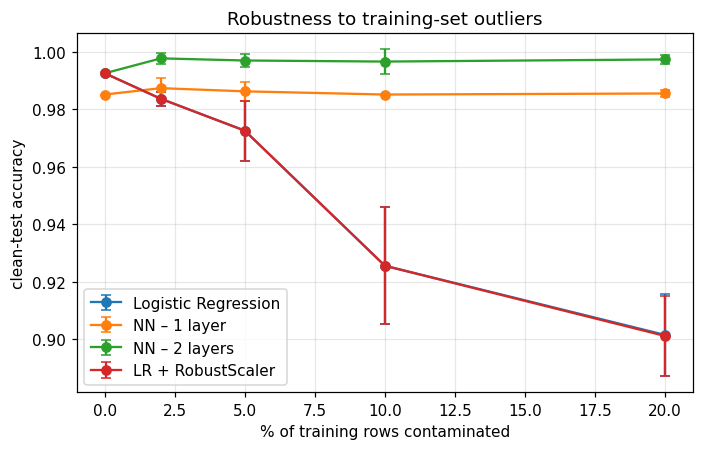

,Logistic Regression,NN – 1 layer,NN – 2 layers,LR + RobustScaler
outlier fraction,,,,
0%,0.9926,0.9852,0.9926,0.9926
2%,0.9837,0.9874,0.9978,0.9837
5%,0.9726,0.9863,0.9970,0.9726
10%,0.9256,0.9852,0.9967,0.9256
20%,0.9015,0.9856,0.9974,0.9011


In [10]:
def contaminate(Xr, frac, rng):
    Xc = Xr.copy(); n = len(Xc); k = int(round(frac * n))
    if k == 0: return Xc
    rows = rng.choice(n, k, replace=False); sd = Xr.std(0)
    for r in rows:
        feats = rng.choice(Xr.shape[1], size=rng.integers(1, 3), replace=False)
        Xc[r, feats] += rng.choice([-1, 1], size=len(feats)) * rng.uniform(4, 8, size=len(feats)) * sd[feats]
    return Xc

fracs = [0.0, 0.02, 0.05, 0.10, 0.20]
rob = {name: np.zeros((len(fracs), 10)) for name in ["Logistic Regression", "NN – 1 layer", "NN – 2 layers", "LR + RobustScaler"]}
makers = {"Logistic Regression": make_lr, "NN – 1 layer": make_nn1, "NN – 2 layers": make_nn2}
rng = np.random.default_rng(SEED)
for i, fr in enumerate(fracs):
    for rep in range(10):
        Xc = contaminate(X_train_raw, fr, rng)
        sc = StandardScaler().fit(Xc)
        for name, mk in makers.items():
            rob[name][i, rep] = mk().fit(sc.transform(Xc), y_train).score(sc.transform(X_test_raw), y_test)
        # control experiment: is LR's weakness the outlier-sensitive StandardScaler rather than the model itself?
        rs = RobustScaler().fit(Xc)   # median / IQR instead of mean / std
        rob["LR + RobustScaler"][i, rep] = make_lr().fit(rs.transform(Xc), y_train).score(rs.transform(X_test_raw), y_test)

rob_table = pd.DataFrame({n: v.mean(1) for n, v in rob.items()}, index=[f"{int(f*100)}%" for f in fracs]).rename_axis("outlier fraction")
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for n, v in rob.items():
    ax.errorbar([f * 100 for f in fracs], v.mean(1), yerr=v.std(1), marker="o", capsize=3, label=n)
ax.set(xlabel="% of training rows contaminated", ylabel="clean-test accuracy", title="Robustness to training-set outliers"); ax.legend()
plt.tight_layout(); savefig("07_outlier_robustness"); plt.show()
rob_table.round(4)

### 5.2 Interpretability
*Logistic regression* exposes one coefficient per feature (sign = direction, magnitude = strength; $e^{w}$ = odds-ratio per +1σ). The *neural network* has no such direct read-out, so permutation importance (drop in test accuracy when one feature is shuffled) is used as a post-hoc approximation.

Number of learnable parameters – LR: 5 | NN-1: 49 | NN-2: 225


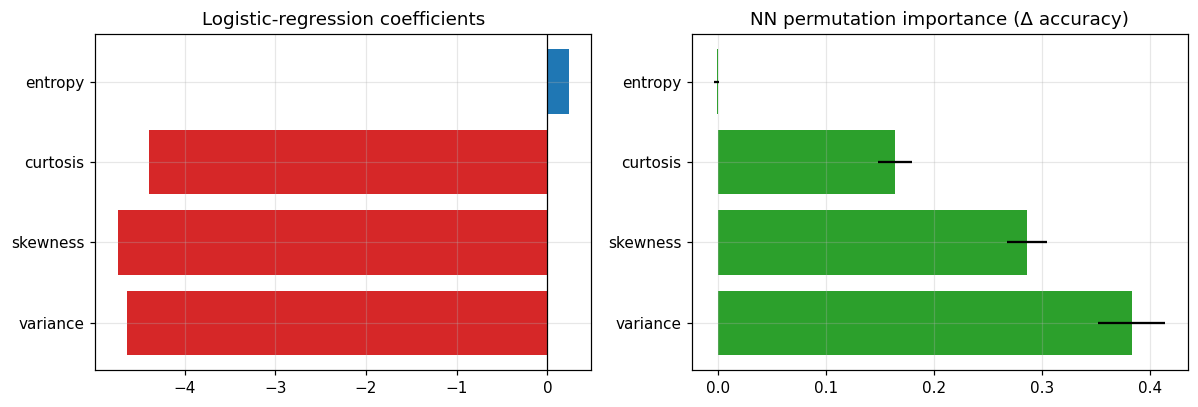

,coefficient (per +1σ),odds ratio,LR permutation imp.,NN permutation imp.
variance,-4.6347,0.0097,0.3998,0.3833
skewness,-4.7386,0.0088,0.3025,0.2862
curtosis,-4.3971,0.0123,0.1695,0.1642
entropy,0.2355,1.2655,0.0000,-0.0014


In [11]:
# Interpretability is read off the λ = 1 model: its coefficients are moderate, whereas the almost-unregularised
# model (C ≈ 600) has huge, unstable weights because the classes are nearly separable.
coef_df = pd.DataFrame({"coefficient (per +1σ)": lr_l2.coef_[0]}, index=FEATURES)
coef_df["odds ratio"] = np.exp(coef_df["coefficient (per +1σ)"])
nn1_fit = models["NN – 1 hidden layer (8)"]
pi = permutation_importance(nn1_fit, X_test, y_test, n_repeats=30, random_state=SEED, scoring="accuracy")
pi_lr = permutation_importance(lr_l2, X_test, y_test, n_repeats=30, random_state=SEED, scoring="accuracy")
coef_df["LR permutation imp."] = pi_lr.importances_mean
coef_df["NN permutation imp."] = pi.importances_mean
print("Number of learnable parameters – LR:", X_train.shape[1] + 1,
      "| NN-1:", sum(c.size for c in nn1_fit.coefs_) + sum(i.size for i in nn1_fit.intercepts_),
      "| NN-2:", sum(c.size for c in models['NN – 2 hidden layers (16, 8)'].coefs_) + sum(i.size for i in models['NN – 2 hidden layers (16, 8)'].intercepts_))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].barh(FEATURES, coef_df["coefficient (per +1σ)"], color=["tab:red" if c < 0 else "tab:blue" for c in coef_df["coefficient (per +1σ)"]])
ax[0].set_title("Logistic-regression coefficients"); ax[0].axvline(0, color="k", lw=0.8)
ax[1].barh(FEATURES, coef_df["NN permutation imp."], xerr=pi.importances_std, color="tab:green")
ax[1].set_title("NN permutation importance (Δ accuracy)")
plt.tight_layout(); savefig("08_interpretability"); plt.show()
coef_df.round(4)

### Interpretation – Task 4 (accuracy, generalisation, outliers, interpretability)
**Accuracy and generalisation on clean data.**

| Model | Test acc | Precision | Recall | F1 | Train–test gap | Repeated-CV acc |
|---|---|---|---|---|---|---|
| Logistic regression (tuned λ) | 99.26 % | 98.39 % | 100 % | 99.19 % | 0.46 pp | 99.63 ± 0.25 % |
| NN, 1 hidden layer (8) | 98.52 % | 96.83 % | 100 % | 98.39 % | 1.02 pp | 99.54 ± 0.45 % |
| NN, 2 hidden layers (16, 8) | 99.26 % | 98.39 % | 100 % | 99.19 % | 0.65 pp | 99.72 ± 0.33 % |

All three reach ROC-AUC = 1.00 and 100 % recall; the differences on the test split are 2 notes at most, so they are **practically tied**. The deeper network is nominally best in CV, the shallow one nominally worst and also the most variable. The learning curves show every model above 99 % even with ≈ 85 training rows; logistic regression plateaus (≈ 99.7 %) by ≈ 200 rows, the networks need ≈ 500, and train and validation curves nearly coincide, i.e. no model over-fits.

**Robustness to outliers (§5.1).** With clean training data the three models are equal, but as training contamination grows the **linear model degrades sharply** (99.3 % → 92.6 % at 10 % and 90.2 % at 20 % outliers) whereas the networks hardly move (NN-1: 98.5 % → 98.6 %; NN-2: 99.3 % → 99.7 %). The RobustScaler control shows this is *not* a scaling artefact (LR + RobustScaler ≈ the same curve): the logistic loss grows linearly with the size of a margin violation, so a few extreme points drag the single hyperplane away from the true boundary, while a network can fit local pockets around them without tilting the global boundary. *Caveat:* this is a stress test with synthetic, label-consistent leverage points; real contamination may behave differently.

**Interpretability (§5.2).** Logistic regression is transparent: one signed weight per feature; a +1σ increase in variance, skewness or curtosis multiplies the odds of class 1 by ≈ 0.009–0.012 (all three push towards class 0), and entropy has a negligible effect (coefficient +0.24, permutation importance 0). The network has 49 – 225 weights with no direct meaning; post-hoc permutation importance reproduces the *same* ranking (variance > skewness > curtosis ≫ entropy), which is reassuring, but it is an approximation and only global.

## 6. Dimensionality reduction with PCA
PCA is **unsupervised**: it finds orthogonal directions of maximal variance, not of maximal class separation. It is fitted on the standardised training data inside a pipeline so that CV folds do not leak.

Explained variance ratio : [0.5461 0.3214 0.0898 0.0427]
Cumulative               : [0.5461 0.8675 0.9573 1.    ]

Loadings:
      variance  skewness  curtosis  entropy
PC1     0.278     0.639    -0.616   -0.368
PC2     0.735    -0.063    -0.129    0.663
PC3     0.615    -0.135     0.495   -0.599
PC4    -0.063     0.755     0.599    0.259


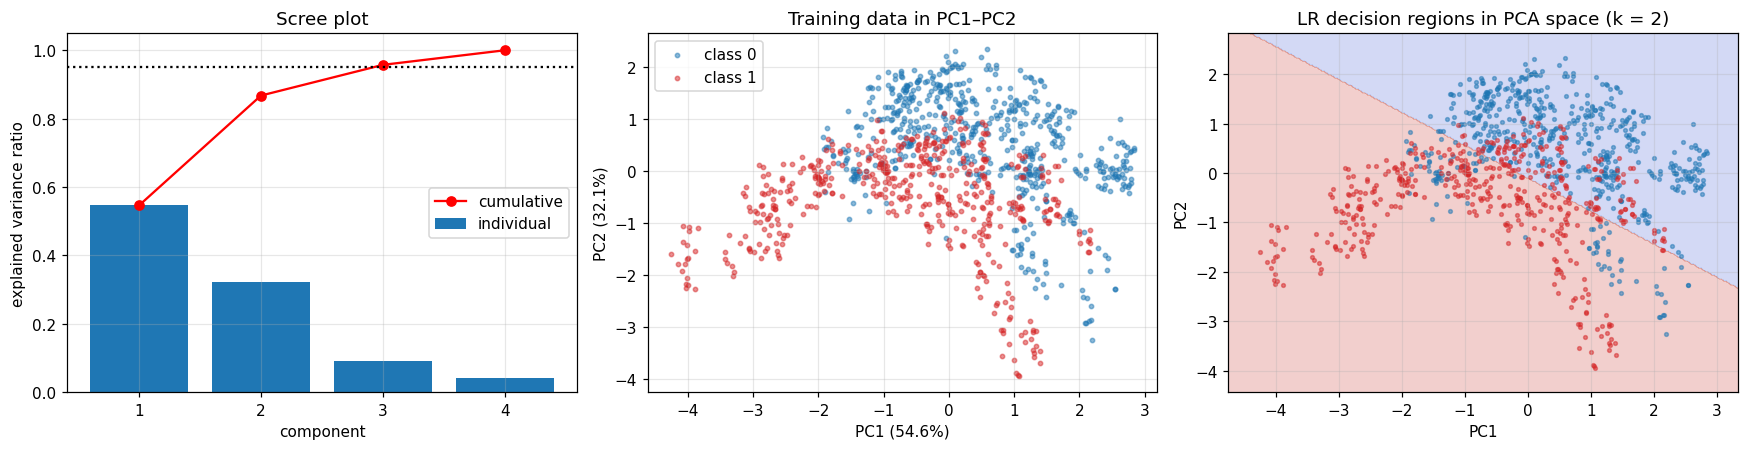

In [12]:
pca_full = PCA().fit(X_train)
evr = pca_full.explained_variance_ratio_
load = pd.DataFrame(pca_full.components_, columns=FEATURES, index=[f"PC{i+1}" for i in range(4)])
print("Explained variance ratio :", evr.round(4))
print("Cumulative               :", np.cumsum(evr).round(4))
print("\nLoadings:\n", load.round(3))

Z = pca_full.transform(X_train)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].bar(range(1, 5), evr, label="individual"); ax[0].plot(range(1, 5), np.cumsum(evr), "ro-", label="cumulative")
ax[0].axhline(0.95, color="k", ls=":"); ax[0].set(xlabel="component", ylabel="explained variance ratio", title="Scree plot"); ax[0].set_xticks(range(1, 5)); ax[0].legend()
for c, col in zip([0, 1], ["tab:blue", "tab:red"]):
    ax[1].scatter(Z[y_train == c, 0], Z[y_train == c, 1], s=8, alpha=0.5, c=col, label=f"class {c}")
ax[1].set(xlabel=f"PC1 ({evr[0]:.1%})", ylabel=f"PC2 ({evr[1]:.1%})", title="Training data in PC1–PC2"); ax[1].legend()
# decision boundary of LR in the 2-D PCA space
lr_pc2 = LogisticRegression(C=BEST_C, max_iter=10000).fit(Z[:, :2], y_train)
gx, gy = np.meshgrid(np.linspace(Z[:, 0].min() - .5, Z[:, 0].max() + .5, 300), np.linspace(Z[:, 1].min() - .5, Z[:, 1].max() + .5, 300))
ax[2].contourf(gx, gy, lr_pc2.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape), alpha=0.25, cmap="coolwarm")
for c, col in zip([0, 1], ["tab:blue", "tab:red"]):
    ax[2].scatter(Z[y_train == c, 0], Z[y_train == c, 1], s=6, alpha=0.5, c=col)
ax[2].set(xlabel="PC1", ylabel="PC2", title="LR decision regions in PCA space (k = 2)")
plt.tight_layout(); savefig("09_pca_overview"); plt.show()

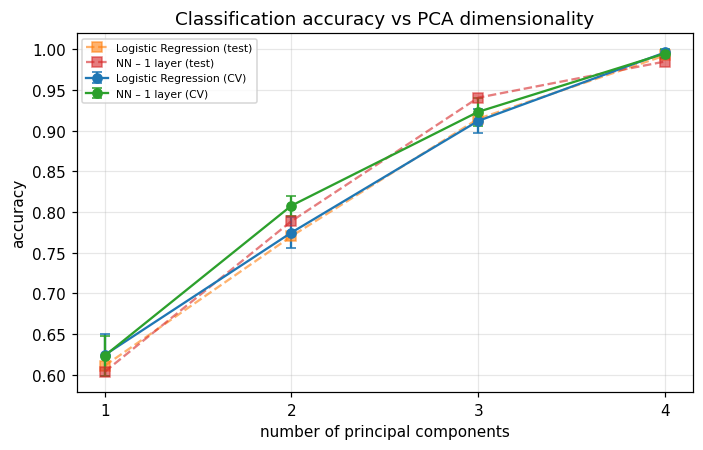

,Classifier,PCA components,Variance kept,Train acc,Test acc,Test F1,CV acc,CV std,Space
0,Logistic Regression,1,0.5461,0.6252,0.6111,0.5333,0.6243,0.0255,reduced
1,Logistic Regression,2,0.8675,0.7737,0.7704,0.7559,0.7749,0.0194,reduced
2,Logistic Regression,3,0.9573,0.9119,0.9148,0.9098,0.9122,0.0145,reduced
3,Logistic Regression,4,1.0000,0.9972,0.9926,0.9919,0.9963,0.0025,original (rotation only)
4,NN – 1 layer,1,0.5461,0.6280,0.6037,0.5286,0.6234,0.0248,reduced
5,NN – 1 layer,2,0.8675,0.8098,0.7889,0.7865,0.8080,0.0122,reduced
6,NN – 1 layer,3,0.9573,0.9341,0.9407,0.9360,0.9233,0.0174,reduced
7,NN – 1 layer,4,1.0000,0.9954,0.9852,0.9839,0.9950,0.0049,original (rotation only)


In [13]:
rows = []
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
for clf_name, mk in [("Logistic Regression", make_lr), ("NN – 1 layer", make_nn1)]:
    for k in [1, 2, 3, 4]:
        pipe = make_pipeline(StandardScaler(), PCA(n_components=k), mk()).fit(X_train_raw, y_train)
        pred = pipe.predict(X_test_raw)
        cvs = cross_val_score(make_pipeline(StandardScaler(), PCA(n_components=k), mk()), X_train_raw, y_train, cv=cv_rep)
        rows.append({"Classifier": clf_name, "PCA components": k, "Variance kept": np.cumsum(evr)[k - 1],
                     "Train acc": pipe.score(X_train_raw, y_train), "Test acc": accuracy_score(y_test, pred),
                     "Test F1": f1_score(y_test, pred), "CV acc": cvs.mean(), "CV std": cvs.std()})
pca_table = pd.DataFrame(rows)
pca_table["Space"] = np.where(pca_table["PCA components"] == 4, "original (rotation only)", "reduced")
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for clf_name, g in pca_table.groupby("Classifier"):
    ax.errorbar(g["PCA components"], g["CV acc"], yerr=g["CV std"], marker="o", capsize=3, label=f"{clf_name} (CV)")
    ax.plot(g["PCA components"], g["Test acc"], "s--", alpha=0.6, label=f"{clf_name} (test)")
ax.set(xlabel="number of principal components", ylabel="accuracy", title="Classification accuracy vs PCA dimensionality"); ax.set_xticks([1, 2, 3, 4]); ax.legend(fontsize=7)
plt.tight_layout(); savefig("10_pca_accuracy"); plt.show()
pca_table.round(4)

### Interpretation – Task 5
* **Variance structure.** PC1 explains 54.6 %, PC2 32.1 %, PC3 9.0 %, PC4 4.3 %; two components keep 86.8 % and three keep 95.7 % of the variance. PC1 contrasts skewness (+0.64) with curtosis (−0.62) and entropy (−0.37); PC2 is mostly variance (+0.74) and entropy (+0.66).
* **Performance.** Repeated-CV accuracy (logistic regression / 1-hidden-layer NN): **1 PC 62.4 / 62.3 %, 2 PCs 77.5 / 80.8 %, 3 PCs 91.2 / 92.3 %, 4 PCs (no reduction) 99.6 / 99.5 %.** Every reduced space is clearly worse than the original, even the 95 %-variance one (3 PCs, −8 pp for LR, −7 pp for the NN).
* **Why.** PCA is unsupervised: it keeps the directions with the largest *variance*, not the largest *class separation*. Here, the discriminative information sits in a low-variance direction – PC4 holds only 4.3 % of the variance but lifts accuracy from ≈ 91 % to ≈ 99.6 %; the PC1–PC2 scatter shows heavily overlapping classes. Mixing the uninformative *entropy* feature into the top components makes things worse.
* **Does PCA help?** **No.** With only four features there is no dimensionality problem to solve, the 4-component PCA is merely a rotation (identical accuracy to the raw space), and compression costs accuracy. The neural network recovers a little more than LR in the compressed space (+3 pp at k = 2) because it can bend the boundary, but not enough to matter. If a smaller input is wanted, *supervised* selection (dropping entropy, §4) is the better route; PCA is only a good idea when features are many and redundant.

## 7. Statistical significance testing – Friedman test and one-way ANOVA
**Design.** Six models are evaluated on *identical* folds of **5-fold stratified CV repeated 6 times (30 folds)**; accuracy per fold is the response. The 30 folds act as *blocks* for the Friedman test (non-parametric, paired, rank-based) and as replicates for the one-way ANOVA (parametric).

* H₀ (Friedman): all models have the same median rank across folds.
* H₀ (ANOVA): all models have the same mean accuracy.
* Post-hoc: **Nemenyi** (after Friedman) and **Tukey HSD** (after ANOVA), both α = 0.05.

In [14]:
K_PCA = 2
contenders = {
    "LR (no reg.)":      lambda: make_pipeline(StandardScaler(), LogisticRegression(penalty=None, max_iter=10000)),
    "LR (L2)":           lambda: make_pipeline(StandardScaler(), make_lr()),
    "NN (8)":            lambda: make_pipeline(StandardScaler(), make_nn1()),
    "NN (16, 8)":        lambda: make_pipeline(StandardScaler(), make_nn2()),
    f"LR + PCA({K_PCA})": lambda: make_pipeline(StandardScaler(), PCA(K_PCA), make_lr()),
    f"NN + PCA({K_PCA})": lambda: make_pipeline(StandardScaler(), PCA(K_PCA), make_nn1()),
}
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=SEED)   # same splits for every model
# the whole dataset is used for the model-comparison experiment (CV handles train/test separation)
acc, f1 = {}, {}
for name, mk in contenders.items():
    res = cross_validate(mk(), X, y, cv=rskf, scoring=["accuracy", "f1"])
    acc[name], f1[name] = res["test_accuracy"], res["test_f1"]
acc_df, f1_df = pd.DataFrame(acc), pd.DataFrame(f1)
summary = pd.DataFrame({"mean acc": acc_df.mean(), "std": acc_df.std(), "min": acc_df.min(), "mean F1": f1_df.mean()}).round(4)
summary

,mean acc,std,min,mean F1
LR (no reg.),0.9941,0.0044,0.9852,0.9935
LR (L2),0.9943,0.0041,0.9852,0.9937
NN (8),0.9927,0.0043,0.9815,0.9920
"NN (16, 8)",0.9984,0.0030,0.9889,0.9982
LR + PCA(2),0.7684,0.0247,0.7148,0.7336
NN + PCA(2),0.8044,0.0248,0.7407,0.7861


In [15]:
def nemenyi(scores):
    """scores: (N blocks, k models), higher = better. Returns mean ranks, p-value matrix, critical difference."""
    N, k = scores.shape
    ranks = np.apply_along_axis(lambda r: stats.rankdata(-r), 1, scores)       # rank 1 = best, ties averaged
    mr = ranks.mean(0)
    se = np.sqrt(k * (k + 1) / (12 * N))
    p = np.ones((k, k))
    for i in range(k):
        for j in range(k):
            if i != j: p[i, j] = stats.studentized_range.sf(abs(mr[i] - mr[j]) / se, k, np.inf)
    cd = stats.studentized_range.ppf(0.95, k, np.inf) * se
    return mr, p, cd

def run_tests(score_df, label):
    names = list(score_df.columns); S = score_df.values; N, k = S.shape
    print(f"================  {label}  ================")
    # --- assumptions for ANOVA
    sh = [stats.shapiro(S[:, j]).pvalue for j in range(k)]
    lev = stats.levene(*[S[:, j] for j in range(k)])
    print("Shapiro–Wilk p per model:", dict(zip(names, np.round(sh, 4))))
    print(f"Levene test (equal variances): W = {lev.statistic:.3f}, p = {lev.pvalue:.4f}")
    # --- one-way ANOVA
    F, pa = stats.f_oneway(*[S[:, j] for j in range(k)])
    grand = S.mean(); ssb = N * ((S.mean(0) - grand) ** 2).sum(); sst = ((S - grand) ** 2).sum()
    print(f"\nOne-way ANOVA: F({k-1}, {k*(N-1)}) = {F:.3f}, p = {pa:.3g}, eta² = {ssb/sst:.3f}")
    tuk = stats.tukey_hsd(*[S[:, j] for j in range(k)])
    tuk_p = pd.DataFrame(tuk.pvalue, index=names, columns=names)
    # --- Friedman
    chi2, pf = stats.friedmanchisquare(*[S[:, j] for j in range(k)])
    mr, pn, cd = nemenyi(S)
    print(f"Friedman test: χ²({k-1}) = {chi2:.3f}, p = {pf:.3g}, Kendall's W = {chi2/(N*(k-1)):.3f}")
    print(f"Nemenyi critical difference (α = 0.05) = {cd:.3f} rank units")
    rk = pd.Series(mr, index=names, name="mean rank (1 = best)").sort_values()
    return dict(F=F, p_anova=pa, chi2=chi2, p_friedman=pf, tukey=tuk_p, nemenyi=pd.DataFrame(pn, index=names, columns=names), ranks=rk, cd=cd)

res_acc = run_tests(acc_df, "ACCURACY")
print("\nMean ranks:\n", res_acc["ranks"].round(3).to_string())

================  ACCURACY  ================
Shapiro–Wilk p per model: {'LR (no reg.)': np.float64(0.0046), 'LR (L2)': np.float64(0.0058), 'NN (8)': np.float64(0.0372), 'NN (16, 8)': np.float64(0.0), 'LR + PCA(2)': np.float64(0.8927), 'NN + PCA(2)': np.float64(0.1867)}
Levene test (equal variances): W = 24.572, p = 0.0000

One-way ANOVA: F(5, 174) = 1640.025, p = 2.59e-144, eta² = 0.979


Friedman test: χ²(5) = 134.387, p = 2.79e-27, Kendall's W = 0.896
Nemenyi critical difference (α = 0.05) = 1.377 rank units

Mean ranks:
 NN (16, 8)      1.383
LR (L2)         2.633
LR (no reg.)    2.667
NN (8)          3.317
NN + PCA(2)     5.050
LR + PCA(2)     5.950


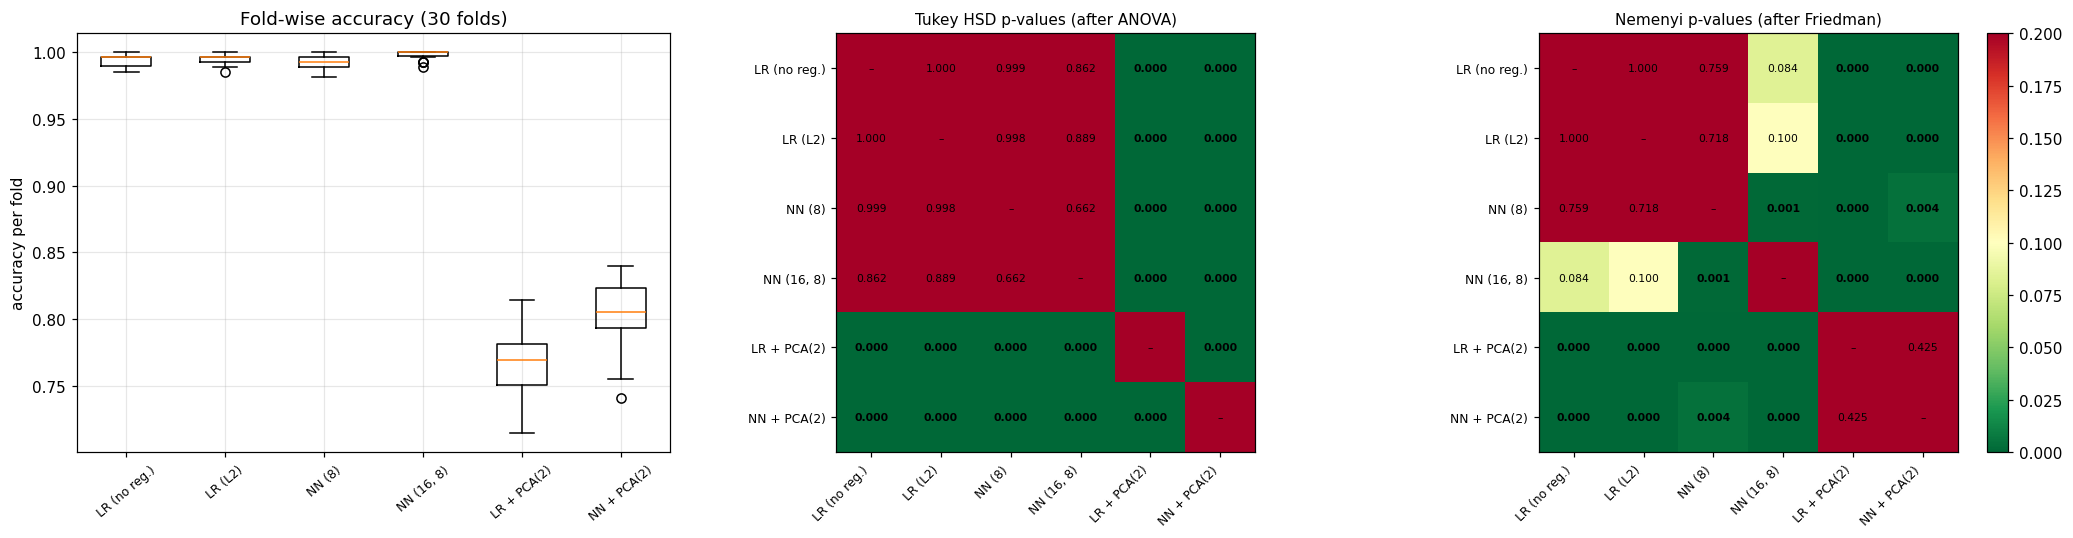

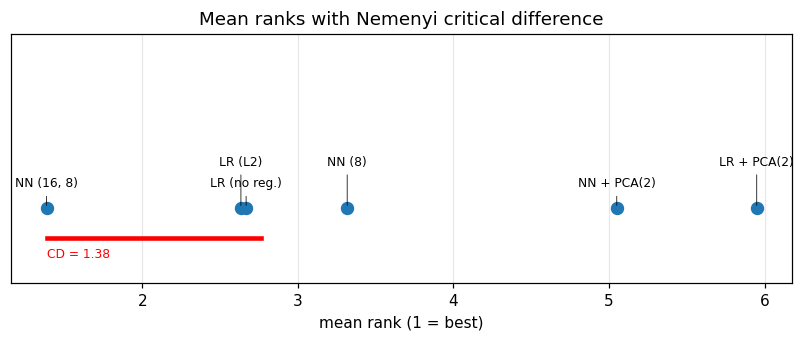

Tukey HSD – significant pairs (p < 0.05):
[('LR (no reg.)', 'LR + PCA(2)', np.float64(0.0)), ('LR (no reg.)', 'NN + PCA(2)', np.float64(0.0)), ('LR (L2)', 'LR + PCA(2)', np.float64(0.0)), ('LR (L2)', 'NN + PCA(2)', np.float64(0.0)), ('NN (8)', 'LR + PCA(2)', np.float64(0.0)), ('NN (8)', 'NN + PCA(2)', np.float64(0.0)), ('NN (16, 8)', 'LR + PCA(2)', np.float64(0.0)), ('NN (16, 8)', 'NN + PCA(2)', np.float64(0.0)), ('LR + PCA(2)', 'NN + PCA(2)', np.float64(0.0))]

Nemenyi – significant pairs (p < 0.05):
[('LR (no reg.)', 'LR + PCA(2)', np.float64(0.0)), ('LR (no reg.)', 'NN + PCA(2)', np.float64(0.0)), ('LR (L2)', 'LR + PCA(2)', np.float64(0.0)), ('LR (L2)', 'NN + PCA(2)', np.float64(0.0)), ('NN (8)', 'NN (16, 8)', np.float64(0.0009)), ('NN (8)', 'LR + PCA(2)', np.float64(0.0)), ('NN (8)', 'NN + PCA(2)', np.float64(0.0045)), ('NN (16, 8)', 'LR + PCA(2)', np.float64(0.0)), ('NN (16, 8)', 'NN + PCA(2)', np.float64(0.0))]


In [16]:
def pmatrix_plot(ax, pm, title):
    im = ax.imshow(pm.values, cmap="RdYlGn_r", vmin=0, vmax=0.2)
    ax.set_xticks(range(len(pm))); ax.set_xticklabels(pm.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pm))); ax.set_yticklabels(pm.index, fontsize=8); ax.grid(False); ax.set_title(title, fontsize=10)
    for i in range(len(pm)):
        for j in range(len(pm)):
            ax.text(j, i, "–" if i == j else f"{pm.values[i, j]:.3f}", ha="center", va="center", fontsize=7,
                    fontweight="bold" if (i != j and pm.values[i, j] < 0.05) else "normal")
    return im

fig, ax = plt.subplots(1, 3, figsize=(19, 5))
ax[0].boxplot(acc_df.values, labels=acc_df.columns); ax[0].tick_params(axis="x", rotation=40, labelsize=8)
ax[0].set(ylabel="accuracy per fold", title="Fold-wise accuracy (30 folds)")
pmatrix_plot(ax[1], res_acc["tukey"], "Tukey HSD p-values (after ANOVA)")
im = pmatrix_plot(ax[2], res_acc["nemenyi"], "Nemenyi p-values (after Friedman)")
plt.colorbar(im, ax=ax[2], fraction=0.046); plt.tight_layout(); savefig("11_significance_tests"); plt.show()

rk = res_acc["ranks"]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.scatter(rk.values, np.zeros(len(rk)), s=60, zorder=3)
for i, (n, r) in enumerate(rk.items()):
    ax.annotate(n, (r, 0), xytext=(0, 14 + 14 * (i % 2)), textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="-", lw=0.5))
ax.plot([rk.min(), rk.min() + res_acc["cd"]], [-0.12, -0.12], "r-", lw=3); ax.text(rk.min(), -0.2, f"CD = {res_acc['cd']:.2f}", color="r", fontsize=8)
ax.set(yticks=[], ylim=(-0.3, 0.7), xlabel="mean rank (1 = best)", title="Mean ranks with Nemenyi critical difference"); ax.grid(axis="y", visible=False)
plt.tight_layout(); savefig("12_rank_cd"); plt.show()

print("Tukey HSD – significant pairs (p < 0.05):")
t = res_acc["tukey"]
print([(a, b, round(t.loc[a, b], 4)) for i, a in enumerate(t.index) for j, b in enumerate(t.columns) if j > i and t.loc[a, b] < 0.05] or "none")
print("\nNemenyi – significant pairs (p < 0.05):")
n_ = res_acc["nemenyi"]
print([(a, b, round(n_.loc[a, b], 4)) for i, a in enumerate(n_.index) for j, b in enumerate(n_.columns) if j > i and n_.loc[a, b] < 0.05] or "none")

In [17]:
# Robustness check of the conclusions using F1 instead of accuracy
res_f1 = run_tests(f1_df, "F1-SCORE (robustness check)")
print("\nMean ranks:\n", res_f1["ranks"].round(3).to_string())

================  F1-SCORE (robustness check)  ================
Shapiro–Wilk p per model: {'LR (no reg.)': np.float64(0.0054), 'LR (L2)': np.float64(0.0065), 'NN (8)': np.float64(0.0414), 'NN (16, 8)': np.float64(0.0), 'LR + PCA(2)': np.float64(0.6474), 'NN + PCA(2)': np.float64(0.2408)}
Levene test (equal variances): W = 27.993, p = 0.0000

One-way ANOVA: F(5, 174) = 1329.006, p = 1.49e-136, eta² = 0.974


Friedman test: χ²(5) = 131.401, p = 1.2e-26, Kendall's W = 0.876
Nemenyi critical difference (α = 0.05) = 1.377 rank units

Mean ranks:
 NN (16, 8)      1.383
LR (L2)         2.717
LR (no reg.)    2.750
NN (8)          3.150
NN + PCA(2)     5.000
LR + PCA(2)     6.000


### 7.1 Focused comparison: the four full-feature models only
The six-model test above is dominated by the two PCA(2) models, which are far worse. The question that matters for the assignment – *is a neural network really better than logistic regression?* – needs the test to be repeated **without** the PCA models. In addition, because CV training sets overlap, fold scores are not independent and plain paired tests are over-confident; the **Nadeau–Bengio corrected resampled t-test** (variance inflated by 1/J + n_test/n_train) with Holm correction is therefore added.

In [18]:
full4 = acc_df[["LR (no reg.)", "LR (L2)", "NN (8)", "NN (16, 8)"]]
res_full = run_tests(full4, "FOUR FULL-FEATURE MODELS (accuracy)")
print("\nMean ranks:\n", res_full["ranks"].round(3).to_string())
print("\nNemenyi p-values:\n", res_full["nemenyi"].round(4).to_string())
print("\nTukey HSD p-values:\n", res_full["tukey"].round(4).to_string())

def corrected_t(d, test_frac=0.25):
    J = len(d); t = d.mean() / np.sqrt((1 / J + test_frac / (1 - test_frac)) * d.var(ddof=1))
    return t, 2 * stats.t.sf(abs(t), J - 1)

pairs, pv = [], []
names4 = list(full4.columns)
for i in range(4):
    for j in range(i + 1, 4):
        d = (full4.iloc[:, j] - full4.iloc[:, i]).values            # positive => column j better
        t, p = corrected_t(d); pairs.append((names4[i], names4[j], d.mean(), t, p)); pv.append(p)
order = np.argsort(pv); holm = np.empty(len(pv)); run = 0
for rank, k_ in enumerate(order):
    run = max(run, min(1, (len(pv) - rank) * pv[k_])); holm[k_] = run
corr_t = pd.DataFrame(pairs, columns=["Model A", "Model B", "mean Δacc (B−A)", "t", "p (raw)"]); corr_t["p (Holm)"] = holm
corr_t["significant @0.05"] = corr_t["p (Holm)"] < 0.05
print("\nNadeau–Bengio corrected resampled t-test:")
corr_t.round(4)

================  FOUR FULL-FEATURE MODELS (accuracy)  ================
Shapiro–Wilk p per model: {'LR (no reg.)': np.float64(0.0046), 'LR (L2)': np.float64(0.0058), 'NN (8)': np.float64(0.0372), 'NN (16, 8)': np.float64(0.0)}
Levene test (equal variances): W = 2.107, p = 0.1031

One-way ANOVA: F(3, 116) = 11.305, p = 1.47e-06, eta² = 0.226
Friedman test: χ²(3) = 49.676, p = 9.36e-11, Kendall's W = 0.552
Nemenyi critical difference (α = 0.05) = 0.856 rank units

Mean ranks:
 NN (16, 8)      1.383
LR (L2)         2.633
LR (no reg.)    2.667
NN (8)          3.317

Nemenyi p-values:
               LR (no reg.)  LR (L2)  NN (8)  NN (16, 8)
LR (no reg.)        1.0000   0.9996  0.2073      0.0007
LR (L2)             0.9996   1.0000  0.1698      0.0010
NN (8)              0.2073   0.1698  1.0000      0.0000
NN (16, 8)          0.0007   0.0010  0.0000      1.0000

Tukey HSD p-values:
               LR (no reg.)  LR (L2)  NN (8)  NN (16, 8)
LR (no reg.)        1.0000   0.9952  0.5534      0.000

,Model A,Model B,mean Δacc (B−A),t,p (raw),p (Holm),significant @0.05
0,LR (no reg.),LR (L2),0.0002,0.3015,0.7652,1.0000,False
1,LR (no reg.),NN (8),-0.0014,-0.5098,0.6141,1.0000,False
2,LR (no reg.),"NN (16, 8)",0.0043,1.5989,0.1207,0.5369,False
3,LR (L2),NN (8),-0.0016,-0.6882,0.4968,1.0000,False
4,LR (L2),"NN (16, 8)",0.0041,1.6616,0.1074,0.5369,False
5,NN (8),"NN (16, 8)",0.0057,2.9447,0.0063,0.0379,True


### Practical deployment cost (prediction latency and model size)

In [19]:
deploy = []
for name, mk in contenders.items():
    pipe = mk().fit(X_train_raw, y_train)
    Xrep = np.tile(X_test_raw, (20, 1))                       # ~5,400 notes
    t0 = time.perf_counter()
    for _ in range(5): pipe.predict(Xrep)
    ms_per_1000 = (time.perf_counter() - t0) / 5 / len(Xrep) * 1000 * 1000
    clf = pipe[-1]
    n_par = (clf.coef_.size + clf.intercept_.size) if hasattr(clf, "coef_") else sum(c.size for c in clf.coefs_) + sum(i.size for i in clf.intercepts_)
    deploy.append({"Model": name, "Parameters": n_par, "Latency (ms / 1000 notes)": ms_per_1000})
pd.DataFrame(deploy).set_index("Model").round(3)

,Parameters,Latency (ms / 1000 notes)
Model,,
LR (no reg.),5,0.068
LR (L2),5,0.059
NN (8),49,0.101
"NN (16, 8)",225,0.136
LR + PCA(2),3,0.081
NN + PCA(2),33,0.136


### Interpretation – Task 6 (Friedman test and one-way ANOVA)
**Six-model test (accuracy over 30 CV folds).** Mean accuracies: NN(16,8) 99.84 %, LR(L2) 99.43 %, LR(no reg.) 99.41 %, NN(8) 99.27 %, NN+PCA(2) 80.4 %, LR+PCA(2) 76.8 %.

| Test | Statistic | p-value | Effect size |
|---|---|---|---|
| One-way ANOVA | F(5, 174) = 1640 | 2.6 × 10⁻¹⁴⁴ | η² = 0.98 |
| Friedman | χ²(5) = 134.4 | 2.8 × 10⁻²⁷ | Kendall's W = 0.90 |

Both reject H₀: the models are **not** equivalent. Post-hoc (Tukey and Nemenyi, α = 0.05): the four full-feature models are significantly better than both PCA(2) models, while the PCA(2) models are the two worst. This confirms Task 5 statistically. Mean ranks: NN(16,8) 1.38 < LR(L2) 2.63 ≈ LR(no reg.) 2.67 < NN(8) 3.32 < NN+PCA(2) 5.05 < LR+PCA(2) 5.95 (Nemenyi CD = 1.38).

**Assumption check.** The ANOVA assumptions are only partly met: Shapiro–Wilk rejects normality for four models (accuracies are bounded near 100 % and discrete) and Levene rejects equal variances (p < 0.001, caused by the high-variance PCA models). Because the effect is enormous (η² = 0.98) the ANOVA conclusion is not in doubt, but the **Friedman test is the more appropriate omnibus test** here (paired, rank-based, no normality assumption). Repeating the tests with F1 instead of accuracy gives the same ordering and conclusions.

**The question that matters – linear vs neural (§7.1).** On the four full-feature models alone: ANOVA F(3,116) = 11.3, p = 1.5 × 10⁻⁶ (η² = 0.23; Levene now fine, p = 0.10) and Friedman χ²(3) = 49.7, p = 9 × 10⁻¹¹ (W = 0.55). Nemenyi and Tukey then single out **NN(16,8) as better than LR (p ≈ 0.001), and than NN(8)**; LR (with/without L2) and NN(8) cannot be told apart.
However, these tests treat the 30 CV folds as independent, which they are not (training sets overlap ≈ 75 %), so they are over-confident. With the Nadeau–Bengio corrected resampled t-test (Holm-adjusted), **NN(16,8) vs LR(L2) is no longer significant** (Δ = +0.41 pp, p_Holm = 0.54); only NN(8) vs NN(16,8) survives (Δ = 0.57 pp, p_Holm = 0.038). In plain terms the deeper network's 0.4 pp edge equals ≈ 5 of the 1,348 notes and is not reliable evidence of superiority over a linear model.

**Practical implications.** (i) Never use PCA(2) here – statistically and practically the worst choice. (ii) On clean data, LR, LR + L2 and the NNs are interchangeable; a 5-parameter linear model that can be audited is enough. (iii) Compute is not a differentiator: scoring 1,000 notes takes ≈ 0.08 ms (LR) vs ≈ 0.14 ms (NN-2). (iv) At a 99.8 % vs 99.4 % level, the consequences of the remaining ≈ 0.2–0.6 % errors should be costed (on the held-out test split every error was a false positive, i.e. a class-0 note labelled class 1) – and a very large, representative hold-out set would be needed to confirm any real gain from the NN.

## 8. Final comparison table

In [20]:
def n_params(m):
    return (m.coef_.size + m.intercept_.size) if hasattr(m, "coef_") else sum(c.size for c in m.coefs_) + sum(i.size for i in m.intercepts_)

final = pd.DataFrame({
    "Test acc": list(nn_table["Test acc"]),
    "Test F1": list(nn_table["F1"]),
    "CV acc": list(nn_table["CV acc (mean)"]),
    "Gap (train-test)": list(nn_table["Gap (train-test)"]),
    "Acc @10% outliers": [rob_table.loc["10%", c] for c in ["Logistic Regression", "NN – 1 layer", "NN – 2 layers"]],
    "Acc @20% outliers": [rob_table.loc["20%", c] for c in ["Logistic Regression", "NN – 1 layer", "NN – 2 layers"]],
    "Parameters": [n_params(m) for m in models.values()],
}, index=nn_table.index)
final.round(4)

,Test acc,Test F1,CV acc,Gap (train-test),Acc @10% outliers,Acc @20% outliers,Parameters
Model,,,,,,,
"Logistic Regression (L2, tuned λ)",0.9926,0.9919,0.9963,0.0046,0.9256,0.9015,5
NN – 1 hidden layer (8),0.9852,0.9839,0.9954,0.0102,0.9852,0.9856,49
"NN – 2 hidden layers (16, 8)",0.9926,0.9919,0.9972,0.0065,0.9967,0.9974,225


## 9. Verdict – linear model or neural network?

| Criterion | Linear (logistic regression) | Neural network (16, 8) | Edge |
|---|---|---|---|
| Accuracy, clean data | 99.4 % (CV) | 99.8 % (CV) | NN nominally, **not significant** after correction |
| Precision / recall / F1 | 98.4 / 100 / 99.2 % | 98.4 / 100 / 99.2 % (test split) | tie |
| Generalisation | train–test gap 0.5 pp | 0.7 pp | tie |
| Robustness to training outliers | falls to 92.6 % (10 %) and 90.2 % (20 %) | stays ≥ 99.6 % under 2–20 % contamination | **NN** |
| Interpretability | 5 signed, readable weights | 225 weights, post-hoc only | **Linear** |
| Cost / maintenance | trivial | small but non-zero | **Linear** |

**Conclusion.** The classes are almost linearly separable, so a **logistic regression is already an effective, defensible solution** – statistically indistinguishable from the best network on clean data, fully interpretable, and with L2 regularisation used only for numerical stability (λ is best kept small). The **two-layer network** is justified only when the training data may contain gross feature outliers (a few percent or more); there its robustness is a real, large advantage (≈ 7–10 pp). My recommendation: **deploy logistic regression** on curated data (with a data-quality check on inputs), and switch to the (16, 8) network – or add robust outlier filtering in front of the linear model – if contamination cannot be controlled. PCA should not be used.